In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Installs & Imports
# ─────────────────────────────────────────────────────────────
!pip install -q tensorflow==2.15.0 scikit-learn matplotlib seaborn

import os, csv, math, shutil, zipfile, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    Callback, ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


2026-06-29 09:10:59.036899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782724259.224491      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782724259.280600      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782724259.774729      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782724259.774787      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782724259.774793      58 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [13]:
# Find exact SRC path
import os

def find_image_folder(base, depth=0):
    if depth > 6: return
    try:
        entries = sorted(os.listdir(base))
    except: return
    dirs = [e for e in entries if os.path.isdir(os.path.join(base, e))]
    # If this folder contains 8+ subfolders, it's likely the class root
    if len(dirs) >= 8:
        print(f"\n✅ Found class root at:\n   {base}\n")
        for d in dirs:
            n = len(os.listdir(os.path.join(base, d)))
            print(f"   {d:<25} {n} files")
        return
    for d in dirs:
        find_image_folder(os.path.join(base, d), depth+1)

find_image_folder("/kaggle/input")


✅ Found class root at:
   /kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification

   battery                   945 files
   biological                985 files
   brown-glass               607 files
   cardboard                 891 files
   clothes                   5325 files
   green-glass               629 files
   metal                     769 files
   paper                     1050 files
   plastic                   865 files
   shoes                     1977 files
   trash                     697 files
   white-glass               775 files


In [14]:
import os, shutil, random

# ← Paste the path printed above here
SRC   = "/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification"
DEST  = "/kaggle/working/dataset"
SPLIT = (0.75, 0.15, 0.10)
SEED  = 42
random.seed(SEED)

# Confirm before splitting
print("Classes found at SRC:")
classes = [c for c in sorted(os.listdir(SRC)) if os.path.isdir(os.path.join(SRC, c))]
for c in classes:
    print(f"  {c:<25} {len(os.listdir(os.path.join(SRC, c)))} images")
print(f"\nTotal classes: {len(classes)}")
print("Starting split...\n")

# Split and copy
for cls in classes:
    cls_path = os.path.join(SRC, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    random.shuffle(imgs)
    n       = len(imgs)
    n_train = int(n * SPLIT[0])
    n_val   = int(n * SPLIT[1])
    splits  = {
        "train" : imgs[:n_train],
        "val"   : imgs[n_train:n_train + n_val],
        "test"  : imgs[n_train + n_val:]
    }
    for split_name, files in splits.items():
        out = os.path.join(DEST, split_name, cls)
        os.makedirs(out, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(cls_path, f), os.path.join(out, f))

    print(f"{cls:<25} train:{len(splits['train']):<5} val:{len(splits['val']):<5} test:{len(splits['test'])}")

print("\n✅ Split complete!")
print(f"   TRAIN → {DEST}/train")
print(f"   VAL   → {DEST}/val")
print(f"   TEST  → {DEST}/test")

Classes found at SRC:
  battery                   945 images
  biological                985 images
  brown-glass               607 images
  cardboard                 891 images
  clothes                   5325 images
  green-glass               629 images
  metal                     769 images
  paper                     1050 images
  plastic                   865 images
  shoes                     1977 images
  trash                     697 images
  white-glass               775 images

Total classes: 12
Starting split...

battery                   train:708   val:141   test:96
biological                train:738   val:147   test:100
brown-glass               train:455   val:91    test:61
cardboard                 train:668   val:133   test:90
clothes                   train:3993  val:798   test:534
green-glass               train:471   val:94    test:64
metal                     train:576   val:115   test:78
paper                     train:787   val:157   test:106
plastic           

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Configuration
# ─────────────────────────────────────────────────────────────
CFG = {
    # ── Paths ───────────────────────────────────────────────
    "DATASET_ROOT"     : "/kaggle/input/datasets/mostafaabla/garbage_classification",
    "TRAIN_DIR"        : "/kaggle/working/dataset/train",
    "VAL_DIR"          : "/kaggle/working/dataset/val",
    "TEST_DIR"         : "/kaggle/working/dataset/test",
    "CHECKPOINT_DIR"   : "/kaggle/working/checkpoints",
    "LOG_DIR"          : "/kaggle/working/logs",
    "OUTPUT_ZIP"       : "/kaggle/working/training_output.zip",

    # ── Model ────────────────────────────────────────────────
    "NUM_CLASSES"      : 12,          # ← updated: battery, biological, brown-glass, cardboard,
                                      #            clothes, green-glass, metal, paper,
                                      #            plastic, shoes, trash, white-glass
    "IMG_SIZE"         : 224,
    "BATCH_SIZE"       : 32,

    # ── Training schedule ────────────────────────────────────
    "WARMUP_EPOCHS"    : 3,
    "PHASE1_EPOCHS"    : 10,
    "TOTAL_EPOCHS"     : 40,
    "UNFREEZE_TOP_N"   : 50,

    # ── Learning rates ───────────────────────────────────────
    "LR_WARMUP_START"  : 1e-5,
    "LR_WARMUP_PEAK"   : 1e-3,
    "LR_PHASE2_PEAK"   : 1e-4,
    "LR_MIN"           : 1e-7,

    # ── SGDR (cosine restarts in phase 2) ────────────────────
    "SGDR_CYCLE_LEN"   : 10,
    "SGDR_DECAY"       : 0.9,

    # ── ReduceLROnPlateau (safety net) ───────────────────────
    "RLROP_PATIENCE"   : 3,
    "RLROP_FACTOR"     : 0.5,

    # ── Early stopping ───────────────────────────────────────
    "ES_PATIENCE"      : 7,
    "ES_MIN_DELTA"     : 0.001,

    # ── Regularisation ───────────────────────────────────────
    "WEIGHT_DECAY"     : 1e-4,
    "LABEL_SMOOTHING"  : 0.1,
    "DROPOUT_1"        : 0.4,
    "DROPOUT_2"        : 0.3,

    # ── Augmentation ─────────────────────────────────────────
    "AUG_ROTATION"     : 15,
    "AUG_ZOOM"         : 0.15,
    "AUG_BRIGHTNESS"   : 0.2,
    "AUG_CONTRAST"     : 0.2,

    # ── Misc ─────────────────────────────────────────────────
    "SEED"             : 42,
    "SAVE_EVERY_N"     : 5,
}

# Derived paths
os.makedirs(CFG["CHECKPOINT_DIR"], exist_ok=True)
os.makedirs(CFG["LOG_DIR"],        exist_ok=True)

LATEST_CKPT = os.path.join(CFG["CHECKPOINT_DIR"], "checkpoint_latest.weights.h5")
BEST_CKPT   = os.path.join(CFG["CHECKPOINT_DIR"], "checkpoint_best.weights.h5")
STATE_FILE  = os.path.join(CFG["CHECKPOINT_DIR"], "train_state.json")
CSV_LOG     = os.path.join(CFG["LOG_DIR"],         "training_history.csv")

tf.random.set_seed(CFG["SEED"])
np.random.seed(CFG["SEED"])

# ── Sanity check — confirm split folders exist ───────────────
print("Config loaded.\n")
for split in ["train", "val", "test"]:
    path = CFG[f"{split.upper()}_DIR"]
    if os.path.isdir(path):
        classes = os.listdir(path)
        total   = sum(len(os.listdir(os.path.join(path, c)))
                      for c in classes if os.path.isdir(os.path.join(path, c)))
        print(f"  {split:<6} → {len(classes)} classes, {total} images  ✅  {path}")
    else:
        print(f"  {split:<6} → NOT FOUND ❌  {path}")
        print(f"           Run the splitter cell first!")

Config loaded.

  train  → 12 classes, 11629 images  ✅  /kaggle/working/dataset/train
  val    → 12 classes, 2321 images  ✅  /kaggle/working/dataset/val
  test   → 12 classes, 1565 images  ✅  /kaggle/working/dataset/test


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Data generators & class weights
# ─────────────────────────────────────────────────────────────
IMG_SHAPE = (CFG["IMG_SIZE"], CFG["IMG_SIZE"])

# Training augmentation pipeline
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    rotation_range     = CFG["AUG_ROTATION"],
    zoom_range         = CFG["AUG_ZOOM"],
    brightness_range   = [1 - CFG["AUG_BRIGHTNESS"], 1 + CFG["AUG_BRIGHTNESS"]],
    channel_shift_range= 20,          # proxy for saturation jitter
    shear_range        = 5,
    fill_mode          = "nearest",
    # NO vertical_flip — waste images have gravity
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)  # no augmentation

train_gen = train_datagen.flow_from_directory(
    CFG["TRAIN_DIR"],
    target_size  = IMG_SHAPE,
    batch_size   = CFG["BATCH_SIZE"],
    class_mode   = "categorical",
    shuffle      = True,
    seed         = CFG["SEED"],
)

val_gen = val_datagen.flow_from_directory(
    CFG["VAL_DIR"],
    target_size  = IMG_SHAPE,
    batch_size   = CFG["BATCH_SIZE"],
    class_mode   = "categorical",
    shuffle      = False,
)

CLASS_NAMES  = list(train_gen.class_indices.keys())
NUM_CLASSES  = len(CLASS_NAMES)
CFG["NUM_CLASSES"] = NUM_CLASSES      # auto-correct if it differed

print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"Train samples : {train_gen.n}")
print(f"Val   samples : {val_gen.n}")

# ── Class weights (handle imbalance) ────────────────────────
labels_flat = train_gen.classes
cw_values   = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(labels_flat),
    y            = labels_flat,
)
class_weights = dict(enumerate(cw_values))
print("\nClass weights:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name:<20} weight={class_weights[i]:.3f}")

Found 11629 images belonging to 12 classes.
Found 2321 images belonging to 12 classes.
Found 12 classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Train samples : 11629
Val   samples : 2321

Class weights:
  [0] battery              weight=1.369
  [1] biological           weight=1.313
  [2] brown-glass          weight=2.130
  [3] cardboard            weight=1.451
  [4] clothes              weight=0.243
  [5] green-glass          weight=2.058
  [6] metal                weight=1.682
  [7] paper                weight=1.231
  [8] plastic              weight=1.495
  [9] shoes                weight=0.654
  [10] trash                weight=1.856
  [11] white-glass          weight=1.668


In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Build model
# ─────────────────────────────────────────────────────────────
def build_model(num_classes: int, cfg: dict) -> keras.Model:
    """
    MobileNetV2 backbone (frozen) + custom classification head.
    Backbone will be partially unfrozen in Phase 2.
    """
    # ── Backbone ────────────────────────────────────────────
    backbone = MobileNetV2(
        input_shape = (cfg["IMG_SIZE"], cfg["IMG_SIZE"], 3),
        include_top = False,
        weights     = "imagenet",
    )
    backbone.trainable = False   # start fully frozen

    # ── Inputs & preprocessing ──────────────────────────────
    inputs = keras.Input(shape=(cfg["IMG_SIZE"], cfg["IMG_SIZE"], 3))
    x = backbone(inputs, training=False)  # training=False keeps BN frozen

    # ── Classification head ─────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)          # 1280-dim vector
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
            256,
            activation   = "relu",
            kernel_regularizer = regularizers.l2(cfg["WEIGHT_DECAY"]),
            name         = "head_dense_256",
        )(x)
    x = layers.Dropout(cfg["DROPOUT_1"])(x)
    x = layers.Dense(
            128,
            activation   = "relu",
            kernel_regularizer = regularizers.l2(cfg["WEIGHT_DECAY"]),
            name         = "head_dense_128",
        )(x)
    x = layers.Dropout(cfg["DROPOUT_2"])(x)
    outputs = layers.Dense(
            num_classes,
            activation   = "softmax",
            name         = "head_output",
        )(x)

    model = keras.Model(inputs, outputs, name="WasteClassifier")
    return model, backbone


model, backbone = build_model(NUM_CLASSES, CFG)
model.summary(line_length=100)
print(f"\nBackbone params : {backbone.count_params():,}")
print(f"Total    params : {model.count_params():,}")


Model: "WasteClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)                 │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ mobilenetv2_1.00_224 (Functional)          │ (None, 7, 7, 1280)              │         2,257,984 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d_1                 │ (None, 1280)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_1 (BatchNormalization) │ (None, 1280)                    │             5,120 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ head_dense_256 (Dense)                     │ (None, 256)                     │           327,936 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_2 (Dropout)                        │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ head_dense_128 (Dense)                     │ (None, 128)                     │            32,896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_3 (Dropout)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ head_output (Dense)                        │ (None, 12)                      │             1,548 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 2,625,484 (10.02 MB)

 Trainable params: 364,940 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Backbone params : 2,257,984
Total    params : 2,625,484


In [36]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Custom LR scheduler callback (Keras 3 compatible)
# ─────────────────────────────────────────────────────────────
class WarmupCosineScheduler(Callback):

    def __init__(self, cfg):
        super().__init__()
        self.cfg     = cfg
        self.history = []

    def _compute_lr(self, epoch: int) -> float:
        cfg   = self.cfg
        p1_end = cfg["PHASE1_EPOCHS"]
        warm   = cfg["WARMUP_EPOCHS"]

        if epoch < p1_end:
            if epoch < warm:
                # Linear warmup
                frac = epoch / max(warm - 1, 1)
                lr   = cfg["LR_WARMUP_START"] + frac * (cfg["LR_WARMUP_PEAK"] - cfg["LR_WARMUP_START"])
            else:
                # Cosine decay phase 1
                decay_epochs = p1_end - warm
                t            = epoch - warm
                cos_val      = 0.5 * (1 + math.cos(math.pi * t / max(decay_epochs, 1)))
                lr           = cfg["LR_MIN"] + (cfg["LR_WARMUP_PEAK"] - cfg["LR_MIN"]) * cos_val
        else:
            # SGDR — cosine with warm restarts
            t_phase2   = epoch - p1_end
            cycle_len  = cfg["SGDR_CYCLE_LEN"]
            cycle_idx  = t_phase2 // cycle_len
            t_in_cycle = t_phase2 %  cycle_len
            peak_lr    = cfg["LR_PHASE2_PEAK"] * (cfg["SGDR_DECAY"] ** cycle_idx)
            cos_val    = 0.5 * (1 + math.cos(math.pi * t_in_cycle / cycle_len))
            lr         = cfg["LR_MIN"] + (peak_lr - cfg["LR_MIN"]) * cos_val

        return max(lr, cfg["LR_MIN"])

    def on_epoch_begin(self, epoch, logs=None):
        lr = self._compute_lr(epoch)

        # Keras 3 compatible — directly assign the float
        self.model.optimizer.learning_rate = lr
        self.history.append((epoch + 1, lr))

        phase = "WARMUP" if epoch < self.cfg["WARMUP_EPOCHS"] else \
                ("PHASE1" if epoch < self.cfg["PHASE1_EPOCHS"] else "PHASE2")
        print(f"\n[LR Scheduler] Epoch {epoch+1:>3} | {phase:<8} | LR = {lr:.2e}")

    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        if logs is not None:
            logs["lr"] = lr

    def plot(self, save_path=None):
        if not self.history:
            print("No LR history yet.")
            return
        epochs, lrs = zip(*self.history)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(epochs, lrs, color="#2196F3", linewidth=2)
        ax.axvline(self.cfg["PHASE1_EPOCHS"], color="orange", ls="--", label="Phase 2 start")
        ax.axvline(self.cfg["WARMUP_EPOCHS"], color="green",  ls=":",  label="Warmup end")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Learning Rate")
        ax.set_title("LR Schedule — Warmup + Cosine + SGDR")
        ax.set_yscale("log")
        ax.legend()
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150)
        plt.show()


# Preview
_preview = WarmupCosineScheduler(CFG)
print(f"{'Epoch':<8} {'Phase':<10} {'LR':>12}")
print("-" * 32)
for ep in range(0, CFG["TOTAL_EPOCHS"], 5):
    lr    = _preview._compute_lr(ep)
    phase = "WARMUP" if ep < CFG["WARMUP_EPOCHS"] else \
            ("PHASE1" if ep < CFG["PHASE1_EPOCHS"] else "PHASE2")
    print(f"{ep+1:<8} {phase:<10} {lr:>12.2e}")

Epoch    Phase                LR
--------------------------------
1        WARMUP         1.00e-05
6        PHASE1         8.12e-04
11       PHASE2         1.00e-04
16       PHASE2         5.01e-05
21       PHASE2         9.00e-05
26       PHASE2         4.51e-05
31       PHASE2         8.10e-05
36       PHASE2         4.06e-05


In [37]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — State persistence helpers
#           Save / load: epoch, best_val_acc, optimizer state
# ─────────────────────────────────────────────────────────────
def save_state(epoch: int, best_val_acc: float, lr_history: list):
    state = {
        "epoch"        : epoch,
        "best_val_acc" : best_val_acc,
        "timestamp"    : datetime.utcnow().isoformat(),
        "lr_history"   : lr_history,
    }
    with open(STATE_FILE, "w") as f:
        json.dump(state, f, indent=2)


def load_state() -> dict | None:
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE) as f:
            return json.load(f)
    return None


class CheckpointManager(Callback):
    """
    Saves:
      checkpoint_latest.weights.h5   — every epoch  (resume point)
      checkpoint_best.weights.h5     — when val_accuracy improves
      checkpoint_epoch_N.weights.h5  — every SAVE_EVERY_N epochs (rollbacks)
    Also persists training state to JSON so optimizer context is resumable.
    """

    def __init__(self, cfg, lr_scheduler: WarmupCosineScheduler):
        super().__init__()
        self.cfg          = cfg
        self.lr_scheduler = lr_scheduler
        self.best_val_acc = 0.0
        self.start_epoch  = 0

        # Try to restore previous best from state file
        state = load_state()
        if state:
            self.best_val_acc = state.get("best_val_acc", 0.0)
            self.start_epoch  = state.get("epoch", 0)
            print(f"[CheckpointManager] Restored state → best_val_acc={self.best_val_acc:.4f}, "
                  f"start_epoch={self.start_epoch}")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get("val_accuracy", 0.0)

        # 1. Always save latest (resume point)
        self.model.save_weights(LATEST_CKPT)

        # 2. Save best
        if val_acc > self.best_val_acc + self.cfg["ES_MIN_DELTA"]:
            self.best_val_acc = val_acc
            self.model.save_weights(BEST_CKPT)
            print(f"  ✓ New best val_acc={val_acc:.4f} → saved checkpoint_best")

        # 3. Rollback snapshots every N epochs
        if (epoch + 1) % self.cfg["SAVE_EVERY_N"] == 0:
            snap = os.path.join(
                self.cfg["CHECKPOINT_DIR"],
                f"checkpoint_epoch_{epoch+1:03d}.weights.h5"
            )
            self.model.save_weights(snap)
            print(f"  ✓ Rollback snapshot saved: {snap}")

        # 4. Persist state JSON
        save_state(epoch + 1, self.best_val_acc, self.lr_scheduler.history)

In [42]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Phase 2 trigger callback (fixed for Keras 3)
# ─────────────────────────────────────────────────────────────
class Phase2Trigger(Callback):

    def __init__(self, cfg, backbone_ref, optimizer_factory):
        super().__init__()
        self.cfg               = cfg
        self.backbone          = backbone_ref
        self.optimizer_factory = optimizer_factory
        self._triggered        = False

    def on_epoch_end(self, epoch, logs=None):
        # Trigger at END of last phase 1 epoch (epoch index = PHASE1_EPOCHS - 1)
        # So training starts phase 2 correctly from the next epoch
        if epoch == self.cfg["PHASE1_EPOCHS"] - 1 and not self._triggered:
            self._triggered = True
            print(f"\n{'='*60}")
            print(f"  PHASE 2 BEGINS — Unfreezing top {self.cfg['UNFREEZE_TOP_N']} backbone layers")
            print(f"{'='*60}")

            # Unfreeze top N layers only
            total        = len(self.backbone.layers)
            freeze_until = total - self.cfg["UNFREEZE_TOP_N"]
            for i, layer in enumerate(self.backbone.layers):
                layer.trainable = (i >= freeze_until)

            trainable = sum(1 for l in self.backbone.layers if l.trainable)
            frozen    = total - trainable
            print(f"  Backbone: {total} layers | {frozen} frozen | {trainable} trainable")

            # Recompile at end of epoch — safe point, train_function rebuilt next epoch
            self.model.compile(
                optimizer = self.optimizer_factory(self.cfg["LR_PHASE2_PEAK"]),
                loss      = keras.losses.CategoricalCrossentropy(
                                label_smoothing=self.cfg["LABEL_SMOOTHING"]
                            ),
                metrics   = [
                    "accuracy",
                    keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")
                ],
            )
            print(f"  Trainable params after unfreeze: {self.model.count_params():,}")
            print(f"  Model recompiled. Phase 2 starts next epoch.\n")

In [43]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Compile model & build all callbacks
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# CELL 8 — Compile (Keras 3 compatible optimizer)
# ─────────────────────────────────────────────────────────────
def make_optimizer(lr: float):
    return keras.optimizers.Adam(
        learning_rate = lr,
        beta_1        = 0.9,
        beta_2        = 0.999,
        epsilon       = 1e-7,
        weight_decay  = CFG["WEIGHT_DECAY"],   # Adam in Keras 3 supports this
    )

# Phase 1 compile (head only, backbone frozen)
model.compile(
    optimizer = make_optimizer(CFG["LR_WARMUP_START"]),
    loss      = keras.losses.CategoricalCrossentropy(label_smoothing=CFG["LABEL_SMOOTHING"]),
    metrics   = ["accuracy", keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
)

# ── Callbacks ────────────────────────────────────────────────
lr_scheduler   = WarmupCosineScheduler(CFG)

ckpt_manager   = CheckpointManager(CFG, lr_scheduler)

phase2_trigger = Phase2Trigger(CFG, backbone, make_optimizer)

reduce_lr      = ReduceLROnPlateau(
    monitor   = "val_loss",
    patience  = CFG["RLROP_PATIENCE"],
    factor    = CFG["RLROP_FACTOR"],
    min_lr    = CFG["LR_MIN"],
    verbose   = 1,
)

early_stop     = EarlyStopping(
    monitor            = "val_accuracy",
    patience           = CFG["ES_PATIENCE"],
    min_delta          = CFG["ES_MIN_DELTA"],
    restore_best_weights = True,
    verbose            = 1,
)

csv_logger     = CSVLogger(CSV_LOG, append=True)  # append=True supports resume

ALL_CALLBACKS = [
    phase2_trigger,  # recompiles at end of epoch 10 — must be FIRST
    lr_scheduler,    # sets LR at start of each epoch — after recompile
    ckpt_manager,
    reduce_lr,
    early_stop,
    csv_logger,
]

print("All callbacks registered.")


[CheckpointManager] Restored state → best_val_acc=0.9414, start_epoch=10
All callbacks registered.


In [47]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Auto-resume logic
#           Checks for checkpoint_latest; resumes if found
# ─────────────────────────────────────────────────────────────
initial_epoch = 0
state         = load_state()

if os.path.exists(LATEST_CKPT) and state:
    print(f"\n{'─'*50}")
    print(f"  RESUMING from epoch {state['epoch']}")
    print(f"  Best val_acc so far : {state['best_val_acc']:.4f}")
    print(f"{'─'*50}")

    model.load_weights(LATEST_CKPT)
    initial_epoch = state["epoch"]

    # Restore LR scheduler history so it doesn't restart from epoch 0
    if state.get("lr_history"):
        lr_scheduler.history = [tuple(x) for x in state["lr_history"]]

    # If we're resuming into Phase 2, unfreeze backbone NOW before training
    if initial_epoch >= CFG["PHASE1_EPOCHS"]:
        total        = len(backbone.layers)
        freeze_until = total - CFG["UNFREEZE_TOP_N"]
        for i, layer in enumerate(backbone.layers):
            layer.trainable = (i >= freeze_until)
        model.compile(
            optimizer = make_optimizer(CFG["LR_PHASE2_PEAK"]),
            loss      = keras.losses.CategoricalCrossentropy(label_smoothing=CFG["LABEL_SMOOTHING"]),
            metrics   = [
                "accuracy",
                keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")
            ],
        )
        phase2_trigger._triggered = True
        print("  Resumed in Phase 2 — backbone unfrozen and recompiled.")

    print("  Weights loaded. Continuing training...\n")

else:
    print("\nNo checkpoint found — starting fresh training.\n")


──────────────────────────────────────────────────
  RESUMING from epoch 10
  Best val_acc so far : 0.9414
──────────────────────────────────────────────────
  Resumed in Phase 2 — backbone unfrozen and recompiled.
  Weights loaded. Continuing training...



In [48]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — TRAIN
# ─────────────────────────────────────────────────────────────
STEPS_PER_EPOCH   = math.ceil(train_gen.n / CFG["BATCH_SIZE"])
VALIDATION_STEPS  = math.ceil(val_gen.n  / CFG["BATCH_SIZE"])

print(f"Steps per epoch   : {STEPS_PER_EPOCH}")
print(f"Validation steps  : {VALIDATION_STEPS}")
print(f"Training from epoch {initial_epoch+1} to {CFG['TOTAL_EPOCHS']}\n")

history = model.fit(
    train_gen,
    steps_per_epoch  = STEPS_PER_EPOCH,
    validation_data  = val_gen,
    validation_steps = VALIDATION_STEPS,
    epochs           = CFG["TOTAL_EPOCHS"],
    initial_epoch    = initial_epoch,
    class_weight     = class_weights,
    callbacks        = ALL_CALLBACKS,
    verbose          = 1,
)

print("\nTraining complete.")

Steps per epoch   : 364
Validation steps  : 73
Training from epoch 11 to 40


[LR Scheduler] Epoch  11 | PHASE2   | LR = 1.00e-04
Epoch 11/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 176s 421ms/step - accuracy: 0.9021 - loss: 0.9726 - top3_acc: 0.9781 - val_accuracy: 0.8751 - val_loss: 0.9503 - val_top3_acc: 0.9780 - lr: 1.0000e-04 - learning_rate: 1.0000e-04

[LR Scheduler] Epoch  12 | PHASE2   | LR = 9.76e-05
Epoch 12/40


/tmp/ipykernel_58/3637647740.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"    : datetime.utcnow().isoformat(),


364/364 ━━━━━━━━━━━━━━━━━━━━ 135s 372ms/step - accuracy: 0.9320 - loss: 0.8795 - top3_acc: 0.9879 - val_accuracy: 0.9035 - val_loss: 0.8813 - val_top3_acc: 0.9806 - lr: 9.7555e-05 - learning_rate: 9.7555e-05

[LR Scheduler] Epoch  13 | PHASE2   | LR = 9.05e-05
Epoch 13/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 135s 371ms/step - accuracy: 0.9484 - loss: 0.8356 - top3_acc: 0.9921 - val_accuracy: 0.9143 - val_loss: 0.8818 - val_top3_acc: 0.9875 - lr: 9.0460e-05 - learning_rate: 9.0460e-05

[LR Scheduler] Epoch  14 | PHASE2   | LR = 7.94e-05
Epoch 14/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 134s 369ms/step - accuracy: 0.9578 - loss: 0.8017 - top3_acc: 0.9937 - val_accuracy: 0.9298 - val_loss: 0.8365 - val_top3_acc: 0.9854 - lr: 7.9410e-05 - learning_rate: 7.9410e-05

[LR Scheduler] Epoch  15 | PHASE2   | LR = 6.55e-05
Epoch 15/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9703 - loss: 0.7637 - top3_acc: 0.9961  ✓ New best val_acc=0.9522 → saved checkpoint_best
  ✓ Rollback snapshot saved: /kagg

In [49]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Load best weights before evaluation
# ─────────────────────────────────────────────────────────────
if os.path.exists(BEST_CKPT):
    model.load_weights(BEST_CKPT)
    print("Loaded best checkpoint for evaluation.")
else:
    print("Using final weights (no improvement checkpoint found).")


Loaded best checkpoint for evaluation.


Training curves saved → /kaggle/working/logs/training_curves.png


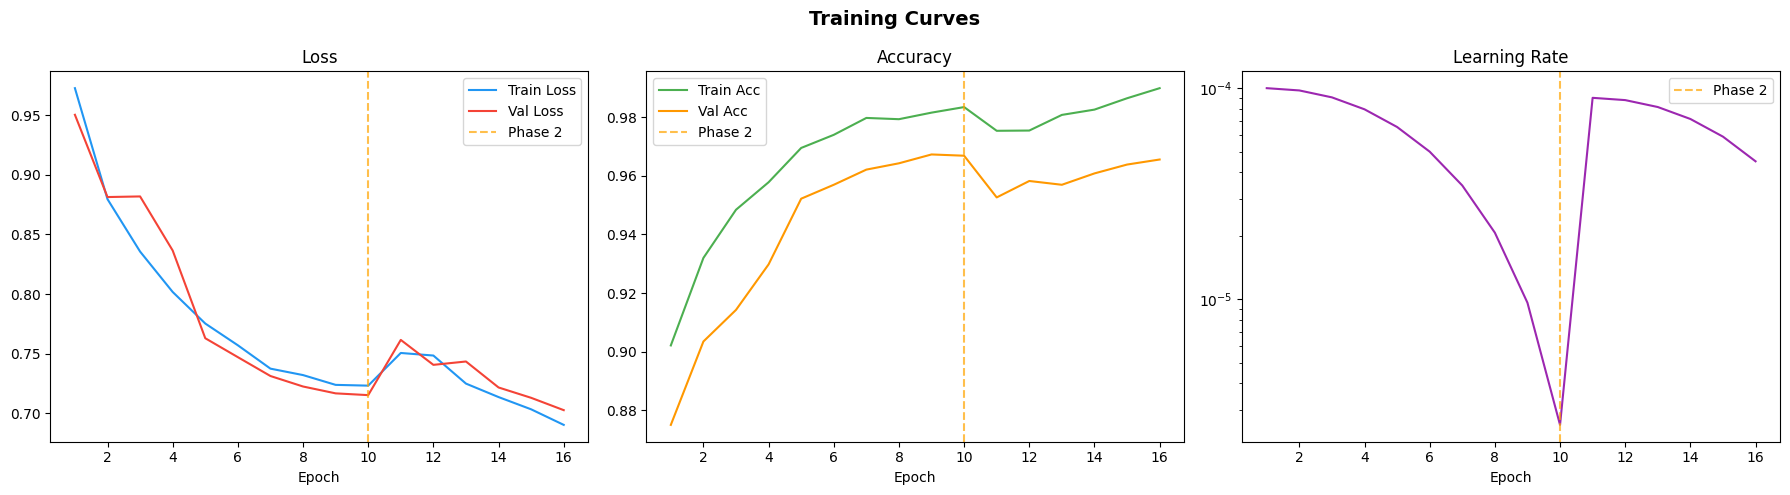

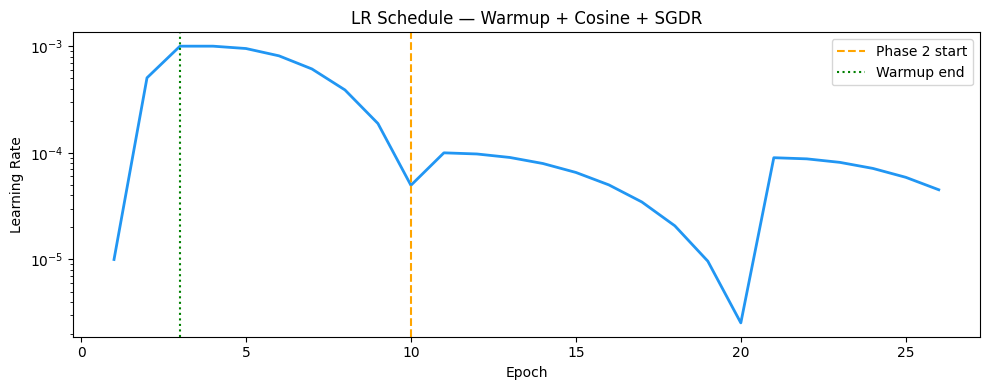

In [50]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Plot training curves
# ─────────────────────────────────────────────────────────────
def plot_training_curves(history_obj, save_path: str = None):
    hist   = history_obj.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training Curves", fontsize=14, fontweight="bold")

    # ── Loss ──
    axes[0].plot(epochs, hist["loss"],     label="Train Loss", color="#2196F3")
    axes[0].plot(epochs, hist["val_loss"], label="Val Loss",   color="#F44336")
    axes[0].axvline(CFG["PHASE1_EPOCHS"], color="orange", ls="--", alpha=0.7, label="Phase 2")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # ── Accuracy ──
    axes[1].plot(epochs, hist["accuracy"],     label="Train Acc", color="#4CAF50")
    axes[1].plot(epochs, hist["val_accuracy"], label="Val Acc",   color="#FF9800")
    axes[1].axvline(CFG["PHASE1_EPOCHS"], color="orange", ls="--", alpha=0.7, label="Phase 2")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    # ── LR ──
    if "lr" in hist:
        axes[2].plot(epochs, hist["lr"], color="#9C27B0")
        axes[2].set_yscale("log")
        axes[2].axvline(CFG["PHASE1_EPOCHS"], color="orange", ls="--", alpha=0.7, label="Phase 2")
        axes[2].set_title("Learning Rate")
        axes[2].set_xlabel("Epoch")
        axes[2].legend()
    else:
        lr_scheduler.plot(save_path=None)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Training curves saved → {save_path}")
    plt.show()


CURVES_PATH = os.path.join(CFG["LOG_DIR"], "training_curves.png")
plot_training_curves(history, save_path=CURVES_PATH)
lr_scheduler.plot(save_path=os.path.join(CFG["LOG_DIR"], "lr_schedule.png"))

73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step

Classification Report:

              precision    recall  f1-score   support

     battery       0.99      0.97      0.98       141
  biological       0.99      0.97      0.98       147
 brown-glass       0.93      0.97      0.95        91
   cardboard       0.97      0.93      0.95       133
     clothes       0.99      0.98      0.99       798
 green-glass       0.96      0.98      0.97        94
       metal       0.92      0.94      0.93       115
       paper       0.96      0.96      0.96       157
     plastic       0.92      0.92      0.92       129
       shoes       0.95      0.99      0.97       296
       trash       0.94      0.97      0.95       104
 white-glass       0.95      0.91      0.93       116

    accuracy                           0.97      2321
   macro avg       0.96      0.96      0.96      2321
weighted avg       0.97      0.97      0.97      2321

Report saved → /kaggle/working/logs/classification_report.txt
Conf

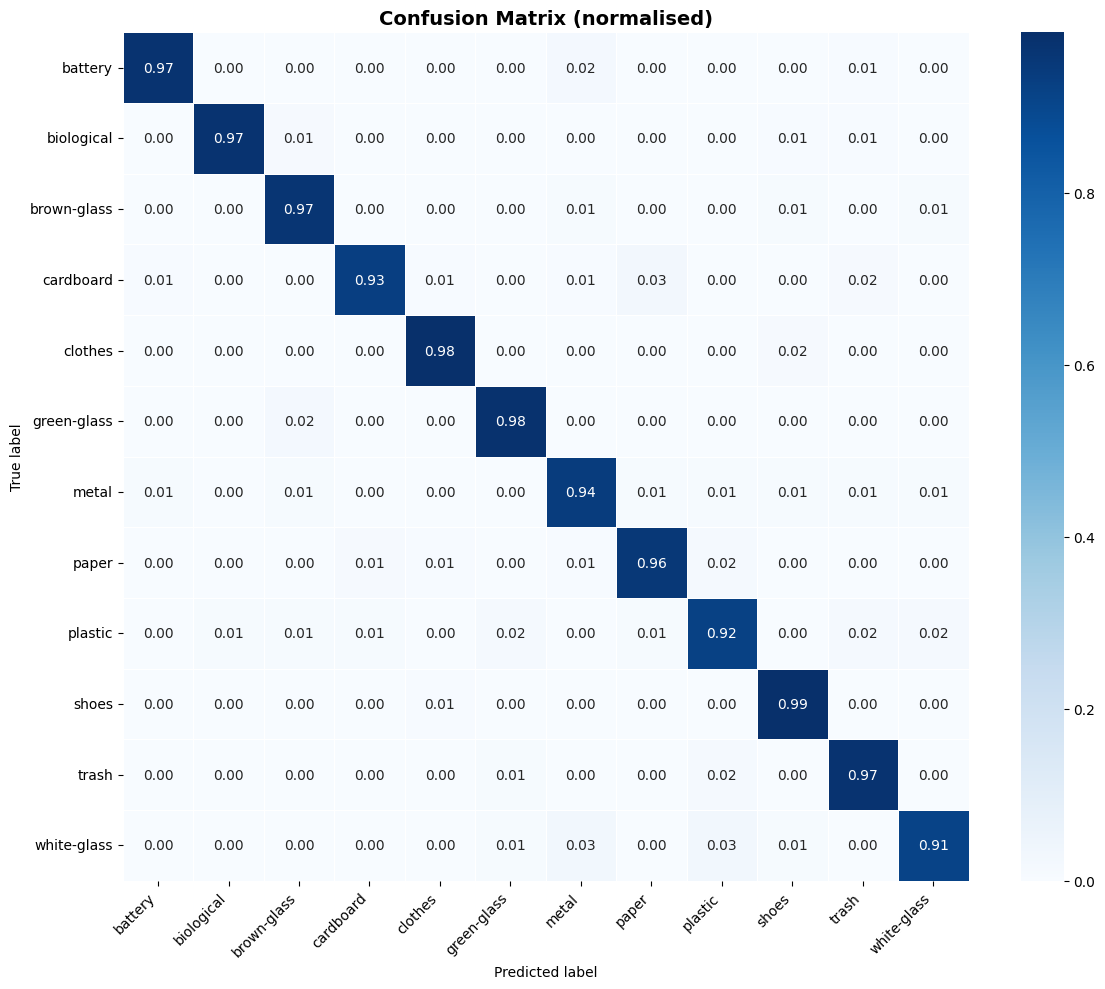

In [51]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Confusion matrix + classification report
# ─────────────────────────────────────────────────────────────
val_gen.reset()
y_pred_probs = model.predict(val_gen, steps=VALIDATION_STEPS, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = val_gen.classes[:len(y_pred)]  # trim to match prediction count

# ── Classification report ──
report_str = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print("\nClassification Report:\n")
print(report_str)

REPORT_PATH = os.path.join(CFG["LOG_DIR"], "classification_report.txt")
with open(REPORT_PATH, "w") as f:
    f.write(report_str)
print(f"Report saved → {REPORT_PATH}")

# ── Confusion matrix plot ──
cm       = confusion_matrix(y_true, y_pred)
cm_norm  = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax  = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot      = True,
    fmt        = ".2f",
    cmap       = "Blues",
    xticklabels= CLASS_NAMES,
    yticklabels= CLASS_NAMES,
    linewidths = 0.5,
    ax         = ax,
)
ax.set_title("Confusion Matrix (normalised)", fontsize=14, fontweight="bold")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = os.path.join(CFG["LOG_DIR"], "confusion_matrix.png")
fig.savefig(CM_PATH, dpi=150)
print(f"Confusion matrix saved → {CM_PATH}")
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Test set evaluation (optional)
# ─────────────────────────────────────────────────────────────
if CFG["TEST_DIR"] and os.path.isdir(CFG["TEST_DIR"]):
    test_datagen = ImageDataGenerator(rescale=1.0 / 255)
    test_gen     = test_datagen.flow_from_directory(
        CFG["TEST_DIR"],
        target_size = IMG_SHAPE,
        batch_size  = CFG["BATCH_SIZE"],
        class_mode  = "categorical",
        shuffle     = False,
    )
    TEST_STEPS = math.ceil(test_gen.n / CFG["BATCH_SIZE"])
    results    = model.evaluate(test_gen, steps=TEST_STEPS, verbose=1)
    print("\nTest results:")
    for name, val in zip(model.metrics_names, results):
        print(f"  {name:<20}: {val:.4f}")
else:
    print("No test directory configured — skipping test evaluation.")

Found 1565 images belonging to 12 classes.
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9652 - loss: 0.7056 - top3_acc: 0.9959

2026-06-29 10:40:18.477700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:40:18.614794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 271ms/step - accuracy: 0.9623 - loss: 0.7203 - top3_acc: 0.9968

Test results:
  loss                : 0.7203
  compile_metrics     : 0.9623


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Save final model (weights + SavedModel) & zip output
# ─────────────────────────────────────────────────────────────
# H5 weights (deployment)
BEST_MODEL_H5  = os.path.join(CFG["LOG_DIR"], "best_model.weights.h5")
model.save_weights(BEST_MODEL_H5)

# Full SavedModel (TF serving)
SAVED_MODEL_DIR = os.path.join(CFG["LOG_DIR"], "full_model_savedmodel")
model.export(SAVED_MODEL_DIR)

# Class names JSON (needed at inference time)
CLASS_JSON = os.path.join(CFG["LOG_DIR"], "class_names.json")
with open(CLASS_JSON, "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

print("\nFiles to zip:")
files_to_zip = [
    BEST_MODEL_H5,
    CURVES_PATH,
    CM_PATH,
    REPORT_PATH,
    CSV_LOG,
    CLASS_JSON,
    os.path.join(CFG["LOG_DIR"], "lr_schedule.png"),
]

with zipfile.ZipFile(CFG["OUTPUT_ZIP"], "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in files_to_zip:
        if os.path.isfile(fp):
            zf.write(fp, arcname=os.path.basename(fp))
            print(f"  + {os.path.basename(fp)}")
    # Add SavedModel directory recursively
    for root, _, files in os.walk(SAVED_MODEL_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arc_name  = os.path.relpath(full_path, CFG["LOG_DIR"])
            zf.write(full_path, arcname=arc_name)
    # Add rollback checkpoints
    for ckpt in Path(CFG["CHECKPOINT_DIR"]).glob("checkpoint_epoch_*.weights.h5"):
        zf.write(str(ckpt), arcname=f"checkpoints/{ckpt.name}")

print(f"\n✅ Output zip → {CFG['OUTPUT_ZIP']}")
print("   Download it from Kaggle Output tab.")

INFO:tensorflow:Assets written to: /kaggle/working/logs/full_model_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/logs/full_model_savedmodel/assets


Saved artifact at '/kaggle/working/logs/full_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_320')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  138945775857168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138945775856784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138945775855056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138945775854672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138945775856016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138945775856400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138942465837200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138942465838736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138945775854096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138942465839696: TensorSpec(shape=(), dtype=tf.resour


Running inference on: /kaggle/working/dataset/val/shoes/shoes951.jpg


2026-06-29 10:40:44.326317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:40:44.460516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


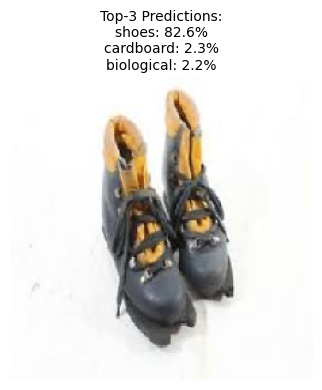

Predictions: {'shoes': 0.8260801434516907, 'cardboard': 0.023168934509158134, 'biological': 0.0222846120595932}


In [ ]:

# ─────────────────────────────────────────────────────────────
# CELL 16 — Quick inference sanity check (single image)
# ─────────────────────────────────────────────────────────────
def predict_single(img_path: str, model, class_names: list, img_size: int = 224):
    """Run model on a single image file and show top-3 predictions."""
    from tensorflow.keras.preprocessing import image as kimage

    img   = kimage.load_img(img_path, target_size=(img_size, img_size))
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    top3  = np.argsort(probs)[::-1][:3]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    title = "\n".join([f"{class_names[i]}: {probs[i]*100:.1f}%" for i in top3])
    plt.title(f"Top-3 Predictions:\n{title}", fontsize=10)
    plt.tight_layout()
    plt.show()

    return {class_names[i]: float(probs[i]) for i in top3}

# ── Example usage ────────────────────────────────────────────
# Grab the first image from val set to sanity-check
import glob
sample_imgs = glob.glob(os.path.join(CFG["VAL_DIR"], "**", "*.jpg"), recursive=True)
if not sample_imgs:
    sample_imgs = glob.glob(os.path.join(CFG["VAL_DIR"], "**", "*.png"), recursive=True)

if sample_imgs:
    test_img = sample_imgs[0]
    print(f"\nRunning inference on: {test_img}")
    preds = predict_single(test_img, model, CLASS_NAMES)
    print("Predictions:", preds)
else:
    print("No sample images found for sanity check.")



In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Final summary printout
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  TRAINING SUMMARY")
print("="*60)
print(f"  Classes          : {CLASS_NAMES}")
print(f"  Total epochs run : {len(history.history['loss']) + initial_epoch}")
print(f"  Best val_acc     : {ckpt_manager.best_val_acc:.4f}")

final_lr = lr_scheduler.history[-1][1] if lr_scheduler.history else 0
print(f"  Final LR         : {final_lr:.2e}")

if "val_accuracy" in history.history and history.history["val_accuracy"]:
    print(f"  Last  val_acc    : {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Last  val_loss   : {history.history['val_loss'][-1]:.4f}")

print(f"\n  Output zip       : {CFG['OUTPUT_ZIP']}")
print(f"  Best weights     : {BEST_MODEL_H5}")
print(f"  CSV log          : {CSV_LOG}")
print("="*60)
print("\nDone. Download training_output.zip from the Kaggle Output tab.")



  TRAINING SUMMARY
  Classes          : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
  Total epochs run : 26
  Best val_acc     : 0.9673
  Final LR         : 4.51e-05
  Last  val_acc    : 0.9655
  Last  val_loss   : 0.7026

  Output zip       : /kaggle/working/training_output.zip
  Best weights     : /kaggle/working/logs/best_model.weights.h5
  CSV log          : /kaggle/working/logs/training_history.csv

Done. Download training_output.zip from the Kaggle Output tab.


In [ ]:
import os

dataset_root = "/kaggle/input"
for entry in os.listdir(dataset_root):
    full = os.path.join(dataset_root, entry)
    print(f"\n📁 {full}")
    for sub in os.listdir(full)[:6]:
        subsub = os.path.join(full, sub)
        count = len(os.listdir(subsub)) if os.path.isdir(subsub) else ""
        print(f"   └─ {sub}  {count}")


📁 /kaggle/input/datasets
   └─ mostafaabla  1
